<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/03_1_Fine_Tune_Pig_Latin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install accelerate datasets peft trl bitsandbytes matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 13.1 MB/s eta 0:00:00


## Harvard Sentences

Conditions of use: The material on this site is freely available for use in VoIP testing, research, development, marketing and any other reasonable application. The material may be copied, downloaded, broadcast, modified, incorporated into web sites or test equipment. We do require that you identify the source of the speech materials as "Open Speech Repository"..

https://www.cs.columbia.edu/~hgs/audio/harvard.html

## Pig Latin

In [ ]:
import re
from string import punctuation

def pig_latin(sentence):
    toks = [t.lower() for t in re.findall(r'\w+|[^\s\w]+', sentence) if len(t) > 0]

    def convert(string):
        # if starts with a vowel, just add "ay"
        # else move the consonants to the end and add "ay"
        if string in punctuation:
            return string
        elif string[0].lower() in {'a', 'e', 'i', 'o', 'u'}:
            return ' ' + string + 'way'
        else:
            beginning_consonants = []
            for i in range(len(string)):
                if string[i].lower() in {'a', 'e', 'i', 'o', 'u'}:
                    break
                beginning_consonants.append(string[i])
            return ' ' + string[i:] + ''.join(beginning_consonants) + 'ay'

    return ''.join([convert(t) for t in toks]).strip()

In [ ]:
pig_latin('How are you doing today?')

'owhay areway ouyay oingday odaytay?'

### Load Harvard Sentences

In [ ]:
!gdown 1pg8hJEdhiHjfcrvo3XzuW4d80xzqnFsl

Downloading...
From: https://drive.google.com/uc?id=1pg8hJEdhiHjfcrvo3XzuW4d80xzqnFsl
To: /content/harvard_sentences.txt
100% 30.5k/30.5k [00:00<00:00, 58.8MB/s]


In [ ]:
from datasets import load_dataset, Split
dataset = load_dataset(path='csv', data_files='harvard_sentences.txt', quotechar='"', split=Split.ALL)
dataset = dataset.shuffle().train_test_split(test_size=0.2)

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence'],
        num_rows: 576
    })
    test: Dataset({
        features: ['sentence'],
        num_rows: 144
    })
})

In [ ]:
dataset['train'][0]

{'sentence': 'A cramp is no small danger on a swim.'}

### Translate Sentences to Pig Latin

In [ ]:
pig_ds = dataset.map(lambda s: {'translated': pig_latin(s['sentence'])})

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

In [ ]:
pig_ds['train'][1]

{'sentence': 'Hoist the load to your left shoulder.',
 'translated': 'oisthay ethay oadlay otay ouryay eftlay ouldershay.'}

### Prompt Dataset

In [ ]:
prompt_pig = pig_ds.rename_columns({'sentence': 'prompt', 'translated': 'completion'}).select_columns(['prompt', 'completion'])

In [ ]:
prompt_pig['train'][0]

{'prompt': 'A cramp is no small danger on a swim.',
 'completion': 'away ampcray isway onay allsmay angerday onway away imsway.'}

## Tokenizer

In [ ]:
from transformers import AutoTokenizer, DataCollatorForLanguageModeling
from torch.utils.data import DataLoader
# from trl import DataCollatorForCompletionOnlyLM

base_model_id = 'microsoft/phi-2'

tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
)
tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
tokenizer.padding_side = 'left'

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [ ]:
response_template = '##[PIGL]##>'
tokenizer.add_special_tokens({'additional_special_tokens': [response_template]})

len(tokenizer)

50297

In [ ]:
tokenizer.pad_token, tokenizer.eos_token, tokenizer.bos_token, tokenizer.unk_token

('<|pad|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>')

In [ ]:
import warnings
import numpy as np
from typing import Any, Literal, Optional, Union
from transformers import DataCollatorForLanguageModeling

class DataCollatorForCompletionOnlyLM(DataCollatorForLanguageModeling):
    """
    Data collator used for completion tasks. It ensures that all the tokens of the labels are set to an 'ignore_index'
    when they do not come from the assistant. This ensure that the loss is only calculated on the completion made by
    the assistant.

    Args:
        response_template (`Union[str, list[int]]`):
            the template form that indicates the start of the response, typically something like '### Response:\n'. It
            can also be passed as tokenized ids, which can be useful when using a tokenizer that encodes the response
            differently if it does not have proper context.
        instruction_template (`Union[str, list[int]]`):
            the template form that indicates the start of the human instruction, typically something like '###
            Human:\n'. Useful for assistant-style conversation datasets. It can also be passed as tokenized ids.
        mlm (`bool`, *optional*, defaults to `False`): Whether to use masked language modeling in the underlying
            `DataCollatorForLanguageModeling` class. Note that this option currently has no effect but is present
             for flexibility and backwards-compatibility.
        ignore_index (`int`, *optional*, defaults to `-100`):
            The index to use to ignore the initial tokens with
    """

    def __init__(
        self,
        response_template: Union[str, list[int]],
        instruction_template: Optional[Union[str, list[int]]] = None,
        *args,
        mlm: bool = False,
        ignore_index: int = -100,
        padding_free: bool = False,
        **kwargs,
    ):
        super().__init__(*args, mlm=mlm, **kwargs)
        warnings.warn(
            "This class is deprecated and will be removed in version 0.20.0. To train on completion only, please use "
            "the parameter `completion_only_loss` of `SFTConfig` instead.",
            DeprecationWarning,
        )

        self.instruction_template = instruction_template
        if isinstance(instruction_template, str):
            # The user provides a string, must tokenize
            self.instruction_token_ids = self.tokenizer.encode(self.instruction_template, add_special_tokens=False)
        else:
            # The user already provides the token ids
            self.instruction_token_ids = instruction_template

        self.response_template = response_template
        if isinstance(response_template, str):
            # The user provides a string, must tokenize
            self.response_token_ids = self.tokenizer.encode(self.response_template, add_special_tokens=False)
        else:
            # The user already provides the token ids
            self.response_token_ids = response_template

        if not self.mlm and self.instruction_template and self.tokenizer.pad_token_id == self.tokenizer.eos_token_id:
            warnings.warn(
                "The pad_token_id and eos_token_id values of this tokenizer are identical. "
                "If you are planning for multi-turn training, "
                "it can result in the model continuously generating questions and answers without eos token. "
                "To avoid this, set the pad_token_id to a different value.",
                UserWarning,
            )

        self.ignore_index = ignore_index
        self.padding_free = padding_free

    def torch_call(self, examples: list[Union[list[int], Any, dict[str, Any]]]) -> dict[str, Any]:
        batch = super().torch_call(examples)

        if self.instruction_template is None:
            for i in range(len(examples)):
                response_token_ids_start_idx = None

                for idx in np.where(batch["labels"][i] == self.response_token_ids[0])[0]:
                    # `response_token_ids` is `'### Response:\n'`, here we are just making sure that the token IDs match
                    if (
                        self.response_token_ids
                        == batch["labels"][i][idx : idx + len(self.response_token_ids)].tolist()
                    ):
                        response_token_ids_start_idx = idx

                if response_token_ids_start_idx is None:
                    warnings.warn(
                        f"Could not find response key `{self.response_template}` in the following instance: "
                        f"{self.tokenizer.decode(batch['input_ids'][i])}. This instance will be ignored in loss "
                        "calculation. Note, if this happens often, consider increasing the `max_length`.",
                        UserWarning,
                    )
                    batch["labels"][i, :] = self.ignore_index
                else:
                    response_token_ids_end_idx = response_token_ids_start_idx + len(self.response_token_ids)

                    # Make pytorch loss function ignore all tokens up through the end of the response key
                    batch["labels"][i, :response_token_ids_end_idx] = self.ignore_index

        else:
            for i in range(len(examples)):
                response_token_ids_idxs = []
                human_token_ids_idxs = []

                for assistant_idx in np.where(batch["labels"][i] == self.response_token_ids[0])[0]:
                    # find the indexes of the start of a response.
                    if (
                        self.response_token_ids
                        == batch["labels"][i][assistant_idx : assistant_idx + len(self.response_token_ids)].tolist()
                    ):
                        response_token_ids_idxs.append(assistant_idx + len(self.response_token_ids))

                if len(response_token_ids_idxs) == 0:
                    warnings.warn(
                        f"Could not find response key `{self.response_template}` in the following instance: "
                        f"{self.tokenizer.decode(batch['input_ids'][i])}. This instance will be ignored in loss "
                        "calculation. Note, if this happens often, consider increasing the `max_length`.",
                        UserWarning,
                    )
                    batch["labels"][i, :] = self.ignore_index

                human_token_ids = self.instruction_token_ids
                for human_idx in np.where(batch["labels"][i] == human_token_ids[0])[0]:
                    # find the indexes of the start of a human answer.
                    if human_token_ids == batch["labels"][i][human_idx : human_idx + len(human_token_ids)].tolist():
                        human_token_ids_idxs.append(human_idx)

                if len(human_token_ids_idxs) == 0:
                    warnings.warn(
                        f"Could not find instruction key `{self.instruction_template}` in the following instance: "
                        f"{self.tokenizer.decode(batch['input_ids'][i])}. This instance will be ignored in loss "
                        "calculation. Note, if this happens often, consider increasing the `max_length`.",
                        UserWarning,
                    )
                    batch["labels"][i, :] = self.ignore_index

                if (
                    len(human_token_ids_idxs) > 0
                    and len(response_token_ids_idxs) > 0
                    and human_token_ids_idxs[0] > response_token_ids_idxs[0]
                ):
                    human_token_ids_idxs = [0] + human_token_ids_idxs

                for idx, (start, end) in enumerate(zip(human_token_ids_idxs, response_token_ids_idxs)):
                    # Make pytorch loss function ignore all non response tokens
                    if idx != 0:
                        batch["labels"][i, start:end] = self.ignore_index
                    else:
                        batch["labels"][i, :end] = self.ignore_index

                if len(response_token_ids_idxs) < len(human_token_ids_idxs):
                    batch["labels"][i, human_token_ids_idxs[-1] :] = self.ignore_index

        if self.padding_free:
            # remove padding, `attention_mask` and add `position_ids`
            attn_mask = batch.pop("attention_mask")
            batch["input_ids"] = batch["input_ids"][attn_mask.bool()].unsqueeze(0)
            batch["position_ids"] = attn_mask.cumsum(1)[attn_mask.bool()].unsqueeze(0) - 1
            batch["labels"] = batch["labels"][attn_mask.bool()].unsqueeze(0)
            batch["labels"][batch["position_ids"] == 0] = self.ignore_index

            # Calculate cumulative sequence lengths for queries and keys to prevent graph breaks during further computations.
            flattened_position_ids = batch["position_ids"].flatten()
            indices_q = torch.arange(
                flattened_position_ids.size(0), device=flattened_position_ids.device, dtype=torch.int32
            )
            batch["cu_seq_lens_q"] = torch.cat(
                (
                    indices_q[flattened_position_ids == 0],
                    torch.tensor(
                        flattened_position_ids.size(), device=flattened_position_ids.device, dtype=torch.int32
                    ),
                )
            ).unsqueeze(0)
            batch["cu_seq_lens_k"] = batch["cu_seq_lens_q"]

            # Determine maximum sequence lengths to prevent graph breaks during further computations.
            batch["max_length_k"] = torch.tensor([flattened_position_ids.max().item() + 1])
            batch["max_length_q"] = batch["max_length_k"]

        return batch

In [ ]:
collator = DataCollatorForCompletionOnlyLM(response_template, tokenizer=tokenizer)

/tmp/ipython-input-1884293905.py:38: DeprecationWarning: This class is deprecated and will be removed in version 0.20.0. To train on completion only, please use the parameter `completion_only_loss` of `SFTConfig` instead.
  warnings.warn(


### Formatting

Let's build a formatting function that takes both prompt and completion, and inserts a particular string that will be used to trigger the translation. This string is the response template.

In [ ]:
def formatting_func(example):
    return f'{example["prompt"]}{response_template}{example["completion"]}' + tokenizer.eos_token

formatting_func(prompt_pig['train'][1])

'Hoist the load to your left shoulder.##[PIGL]##>oisthay ethay oadlay otay ouryay eftlay ouldershay.<|endoftext|>'

In [ ]:
def generate_and_tokenize_prompt(prompt, max_length=128, padding=True):
    result = tokenizer(
        formatting_func(prompt),
        truncation=True,
        max_length=max_length,
        padding="max_length" if padding else False,
    )
    #result["labels"] = result["input_ids"].copy()
    return result

dataset = prompt_pig['train'].map(lambda v: generate_and_tokenize_prompt(v, padding=False))
dataset = dataset.remove_columns(['prompt', 'completion'])
print(dataset[0])

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

{'input_ids': [32, 1067, 696, 318, 645, 1402, 3514, 319, 257, 9422, 13, 50296, 8272, 716, 14751, 2433, 318, 1014, 319, 323, 477, 5796, 323, 8993, 820, 319, 1014, 1497, 545, 82, 1014, 13, 50256], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


576


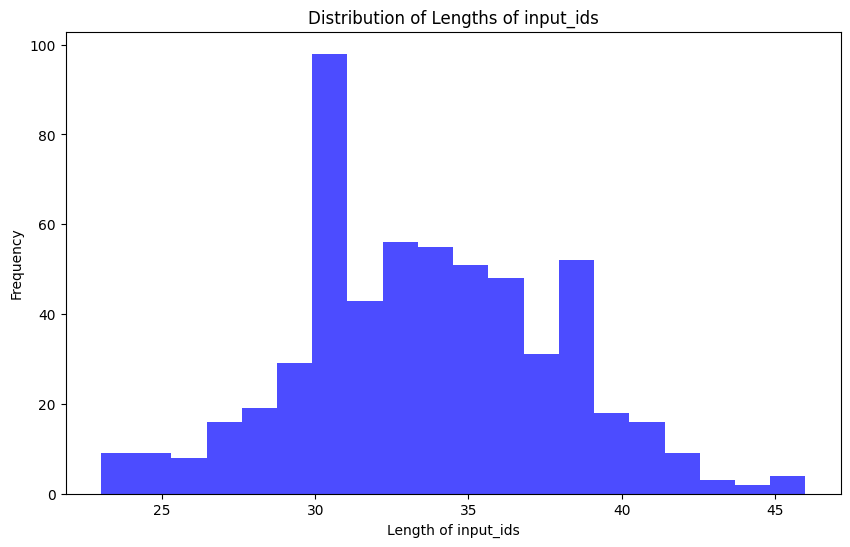

In [ ]:
import matplotlib.pyplot as plt

def plot_data_lengths(tokenized_train_dataset):
    lengths = [len(x['input_ids']) for x in tokenized_train_dataset]
    print(len(lengths))

    # Plotting the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=20, alpha=0.7, color='blue')
    plt.xlabel('Length of input_ids')
    plt.ylabel('Frequency')
    plt.title('Distribution of Lengths of input_ids')
    plt.show()

plot_data_lengths(dataset)

In [ ]:
max_length = 64
tokenized_train_dataset = prompt_pig['train'].map(lambda v: generate_and_tokenize_prompt(v, max_length))
tokenized_val_dataset = prompt_pig['test'].map(lambda v: generate_and_tokenize_prompt(v, max_length))

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

In [ ]:
tokenizer.decode(tokenized_train_dataset[1]['input_ids'])

'<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>Hoist the load to your left shoulder.##[PIGL]##>oisthay ethay oadlay otay ouryay eftlay ouldershay.<|endoftext|>'

## Model

In [ ]:
base_model_id

'microsoft/phi-2'

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

model = AutoModelForCausalLM.from_pretrained(base_model_id, trust_remote_code=True, quantization_config=bnb_config)
# no need
# model.resize_token_embeddings(len(tokenizer))

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
model.model.embed_tokens, len(tokenizer)

(Embedding(51200, 2560), 50297)

In [ ]:
model

PhiForCausalLM(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear8bitLt(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear8bitLt(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear8bitLt(in_features=2560, out_features=2560, bias=True)
          (dense): Linear8bitLt(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear8bitLt(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear8bitLt(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_

In [ ]:
def print_trainable_parameters(model, verbose=False):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for name, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            if verbose:
                print(name)
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [ ]:
print_trainable_parameters(model, verbose=True)

model.embed_tokens.weight
model.layers.0.input_layernorm.weight
model.layers.0.input_layernorm.bias
model.layers.1.input_layernorm.weight
model.layers.1.input_layernorm.bias
model.layers.2.input_layernorm.weight
model.layers.2.input_layernorm.bias
model.layers.3.input_layernorm.weight
model.layers.3.input_layernorm.bias
model.layers.4.input_layernorm.weight
model.layers.4.input_layernorm.bias
model.layers.5.input_layernorm.weight
model.layers.5.input_layernorm.bias
model.layers.6.input_layernorm.weight
model.layers.6.input_layernorm.bias
model.layers.7.input_layernorm.weight
model.layers.7.input_layernorm.bias
model.layers.8.input_layernorm.weight
model.layers.8.input_layernorm.bias
model.layers.9.input_layernorm.weight
model.layers.9.input_layernorm.bias
model.layers.10.input_layernorm.weight
model.layers.10.input_layernorm.bias
model.layers.11.input_layernorm.weight
model.layers.11.input_layernorm.bias
model.layers.12.input_layernorm.weight
model.layers.12.input_layernorm.bias
model.

### LoRA

In [ ]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

In [ ]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "dense"
        "fc1", "fc2",
        "lm_head",
    ],
    modules_to_save=['layernorm', 'embed_tokens'],
    bias="none",
    lora_dropout=0.05,  # Conventional
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(model, config)
peft_model.print_trainable_parameters()

trainable params: 146,519,040 || all params: 2,926,202,880 || trainable%: 5.0071


In [ ]:
print_trainable_parameters(peft_model, verbose=True)

base_model.model.model.embed_tokens.modules_to_save.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.0.mlp.fc2.lora_A.default.weight
base_model.model.model.layers.0.mlp.fc2.lora_B.default.weight
base_model.model.model.layers.0.input_layernorm.modules_to_save.default.weight
base_model.model.model.layers.0.input_layernorm.modules_to_save.default.bias
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight
base_model.mod

In [ ]:
# Some Environment Setup
OUTPUT_DIR = "./results/pigl" # the path to the output directory; where model checkpoints will be saved

In [ ]:
import transformers

training_args = transformers.TrainingArguments(
        output_dir=OUTPUT_DIR,
        warmup_steps=2,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        auto_find_batch_size=True,
        max_steps=500,
        learning_rate=2.5e-5, # Want a small lr for finetuning
        optim="paged_adamw_8bit",
        logging_steps=25,            # When to start reporting loss
        logging_dir="./logs",        # Directory for storing logs
        save_strategy="steps",       # Save the model checkpoint every logging step
        save_steps=500,                # Save checkpoints every 50 steps
        eval_strategy="steps", # Evaluate the model every logging step
        eval_steps=25,               # Evaluate and save checkpoints every 50 steps
        do_eval=True,                # Perform evaluation at the end of training
        report_to="none",
)

In [ ]:
trainer = transformers.Trainer(
    model=peft_model,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    args=training_args,
    data_collator=collator
)

trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:186: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss,Validation Loss
25,5.598400,4.266863
50,3.612700,2.814873
75,2.689800,2.224394
100,2.189600,1.778658
125,1.816900,1.496423
150,1.607400,1.306383
175,1.397800,1.198046
200,1.285200,1.118152
225,1.190300,1.032890
250,1.081500,0.988485


KeyboardInterrupt: 

In [ ]:
OUTPUT_DIR = "./results/pigl" # the path to the output directory; where model checkpoints will be saved
model_ckpt = OUTPUT_DIR + "/stop"

#trainer.save_model(model_ckpt)

## Reloading the Model

In [ ]:
# Downloads and unzips trained adapter
!gdown 1Zwyu3uPC0v-oQHNmT1HidBsjfk2MRTi5
!unzip piglatin_adapter.zip -d ./

Downloading...
From (original): https://drive.google.com/uc?id=1Zwyu3uPC0v-oQHNmT1HidBsjfk2MRTi5
From (redirected): https://drive.google.com/uc?id=1Zwyu3uPC0v-oQHNmT1HidBsjfk2MRTi5&confirm=t&uuid=3c458b25-4e55-4044-9525-7de4b328abef
To: /content/piglatin_adapter.zip
100% 681M/681M [00:14<00:00, 46.4MB/s]
Archive:  piglatin_adapter.zip
  inflating: ./results/pigl/stop/adapter_config.json  
  inflating: ./results/pigl/stop/adapter_model.safetensors  
  inflating: ./results/pigl/stop/README.md  
  inflating: ./results/pigl/stop/training_args.bin  


In [ ]:
base_model_id

'microsoft/phi-2'

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

model = AutoModelForCausalLM.from_pretrained(base_model_id, trust_remote_code=True, quantization_config=bnb_config, device_map='cuda:0')

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
from peft import PeftModel

OUTPUT_DIR = "./results/pigl" # the path to the output directory; where model checkpoints will be saved
model_ckpt = OUTPUT_DIR + "/stop"

fine_tuned_model = PeftModel.from_pretrained(model, model_ckpt)

In [ ]:
fine_tuned_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): PhiForCausalLM(
      (model): PhiModel(
        (embed_tokens): ModulesToSaveWrapper(
          (original_module): Embedding(51200, 2560)
          (modules_to_save): ModuleDict(
            (default): Embedding(51200, 2560)
          )
        )
        (layers): ModuleList(
          (0-31): 32 x PhiDecoderLayer(
            (self_attn): PhiAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2560, out_features=2560, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2560, bias=False)
                )
                (lora_embedding_A): ParameterDi

In [ ]:
eval_prompt = "Luke, I am your father!"
model_input = tokenizer(eval_prompt, return_tensors="pt").to("cuda")
model_input

{'input_ids': tensor([[30730,    11,   314,   716,   534,  2988,     0]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [ ]:
fine_tuned_model.eval()
with torch.no_grad():
    output = fine_tuned_model.generate(**model_input,
                                       max_new_tokens=100,
                                       repetition_penalty=1.1)[0]
    print(tokenizer.decode(output, skip_special_tokens=False))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Luke, I am your father!<|endoftext|>


In [ ]:
eval_prompt = "How are you?"
response_template = '##[PIGL]##>'
model_input = tokenizer(eval_prompt+response_template, return_tensors="pt").to("cuda")

fine_tuned_model.eval()
with torch.no_grad():
    print(tokenizer.decode(fine_tuned_model.generate(**model_input, max_new_tokens=100, repetition_penalty=1.1)[0], skip_special_tokens=False))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


How are you?##[PIGL]##>ehay areway ouyay?<|endoftext|>


In [ ]:
def generate(model, tokenizer, prompt, response_template="", max_new_tokens=100):
    tokenized_input = tokenizer(prompt+response_template, return_tensors="pt")
    input_ids = tokenized_input["input_ids"].cuda()

    model.eval()
    generation_output = model.generate(
        input_ids=input_ids,
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1
    )
    seq = generation_output[0]
    output = tokenizer.decode(seq, skip_special_tokens=False)
    return output.strip()

In [ ]:
max_length = 64
generate(fine_tuned_model, tokenizer, 'how are you doing?', response_template, max_length)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


'how are you doing?##[PIGL]##>owhay away ouyay oingday?<|endoftext|>'

In [ ]:
sample = prompt_pig['train'][7]
generate(fine_tuned_model, tokenizer, sample['prompt'], response_template, max_length)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'The room was crowded with a wild mob.##[PIGL]##>ethay oomray asway uddoredcay ithway away ildwhay obmay.<|endoftext|>'

In [ ]:
with fine_tuned_model.disable_adapter():
    print(generate(fine_tuned_model, tokenizer, sample['prompt']))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The room was crowded with a wild mob.
<|endoftext|>


In [ ]:
with fine_tuned_model.disable_adapter():
    print(generate(fine_tuned_model, tokenizer, sample['prompt'], response_template))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The room was crowded with a wild mob.##[PIGL]##> of the crowd were shouting and screaming, while others were trying to calm them down.
<|endoftext|>
